In [283]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import sklearn.metrics as sm
from sklearn.preprocessing import StandardScaler
import numpy as np


In [284]:
df = pd.read_csv(r"C:\Users\usuario\Documents\Curso Ciencia de Datos UTN\DATA SETS PARA PRACTICAR\insurance.csv")

## EDA

In [285]:
df.head(15)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [286]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [287]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [288]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [289]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [290]:
df.groupby("smoker")["age"].mean()

smoker
no     39.385338
yes    38.514599
Name: age, dtype: float64

In [291]:
df.groupby("smoker")["charges"].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

Observamos la diferencia promedio de gastos médicos que hay entre una persona fumadora y una no fumadora.

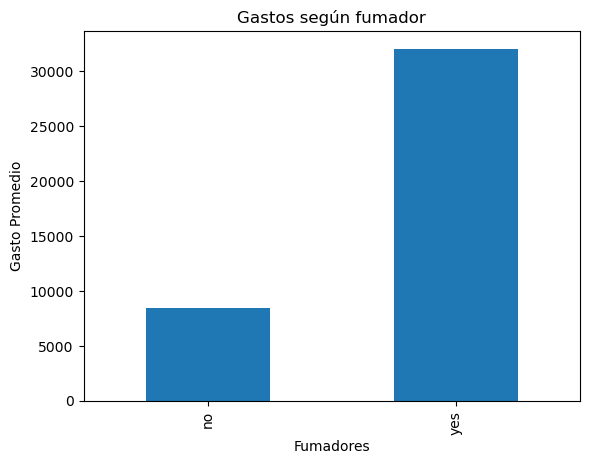

In [292]:
df.groupby("smoker")["charges"].mean().plot(kind="bar")

plt.xlabel("Fumadores")
plt.ylabel("Gasto Promedio")
plt.title("Gastos según fumador")
plt.show()

Convierto la variable Smoker a numérica para poder usar modelo de predicción

In [293]:
df["smoker"]=df["smoker"].map({"yes":1,"no":0})

In [294]:
df["sex"]=df["sex"].map({"male":1,"female":0})

In [295]:
df_nuevo =pd.get_dummies (df, columns = ["region"], drop_first =False)
df_nuevo =df_nuevo.astype(int)
print (df_nuevo.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')


In [296]:
print(df_nuevo["age"].dtype)

int64


In [297]:
print(df_nuevo["age"].isnull().sum())

0


In [298]:
print (df_nuevo.dtypes)

age                 int64
sex                 int64
bmi                 int64
children            int64
smoker              int64
charges             int64
region_northeast    int64
region_northwest    int64
region_southeast    int64
region_southwest    int64
dtype: object


In [299]:
x = df_nuevo[['age', 'sex', 'bmi', 'children', 'smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest']]

y = df_nuevo["charges"]

In [300]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [301]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Usamos un modelo de regresión lineal para predecir los gastos médicos que puede llegar a tener una persona según las variables.

In [302]:
y_pred = model.predict(x_test)

In [303]:
mse = mean_squared_error (y_test, y_pred)
r2= r2_score (y_test, y_pred)
rmse = np.sqrt (mse)
print (f"Error cuadrático medio (MSE): {mse}")
print (f"Coeficiente de determinación (R2): {r2}")
print (f"Raíz del error cuadrático medio (RMSE): {rmse}")

Error cuadrático medio (MSE): 33566439.73530044
Coeficiente de determinación (R2): 0.7837888448800692
Raíz del error cuadrático medio (RMSE): 5793.655127404499


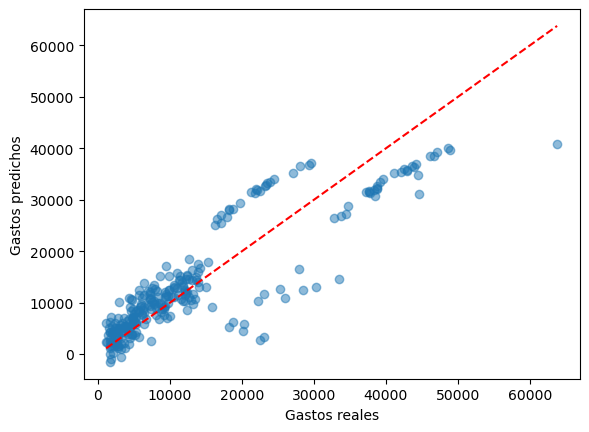

In [304]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Gastos reales")
plt.ylabel("Gastos predichos")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()


Conclusión: el modelo de regresión lineal múltiple muestra una predicción de casi el 80% de efectividad. Los gastos aumentan según las variables mas influyentes, como lo son el índice de masa corporal y si es fumador.